# Solucionando la ecuación de Poisson

_Autores: Hans Petter Langtangen, Anders Logg_

_Adaptado a FEniCSx por Jørgen S. Dokken_


El objetivo de este tutorial es resolver una de las EDPs más básicas, las ecuaciones de Poisson, con unas pocas líneas de código en FEniCSx. Empezaremos introduciendo los objetos más fundamentales de FEniCSx, como “Function”, “FunctionSpace”, “TrialFunction” y “TestFunction”, y aprenderemos a escribir un solucionador básico de EDP. 
Esto incluirá:
- Cómo formular un problema matemático variacional
- Cómo aplicar las condiciones de contorno
- Cómo resolver el sistema lineal discreto
- Cómo visualizar la solución


La ecuación de Poisson es el siguiente problema de valor límite:

\begin{align}
-\nabla^2 u(\mathbf{x}) &= f(\mathbf{x})&&\mathbf{x} \in \Omega\\
u(\mathbf{x}) &= u_D(\mathbf{x})&& \mathbf{x} \in \partial\Omega
\end{align}

Aquí, $u=u(\mathbf{x})$ es la función desconocida, $f=f(\mathbf{x})$ es una función prescrita, $\nabla^2$ es el operador de Laplace, a menudo escrito como $\Delta$, $\Omega$ es el dominio espacial, y $\partial\Omega$ es la frontera de $\Omega$. El problema de Poisson, que incluye tanto la EDP $-\nabla^2 u = f$ como la condición de contorno $u=u_D$ en $\partial\Omega$, es un ejemplo de _problema de valor límite_, que debe plantearse con precisión antes de que tenga sentido empezar a resolverlo numéricamente con FEniCSx. 


En el espacio bidimensional con coordenadas $x$ e $y$, podemos expandir la ecuación de Poisson como

$ -\frac{\partial^2 u}{\partial x^2} - \frac{\partial^2 u}{\partial y^2} = f(x,y)$

La incógnita $u$ es ahora una función de dos variables, $u=u(x,y)$, definida sobre el dominio bidimensional $\Omega$. 

La ecuación de Poisson surge en numerosos contextos físicos, entre ellos
conducción de calor, electrostática, difusión de sustancias, torsión elástica, el flujo de fluidos no viscosos y las ondas de agua. Además, la ecuación
ecuación aparece en estrategias de división numérica para sistemas
complicados, en particular las ecuaciones de Navier-Stokes.

Resolver un problema de valor límite en FEniCSx consiste en los siguientes pasos:

1. Identificar el dominio computacional $\Omega$, la EDP, y sus correspondientes condiciones de contorno y términos fuente $f$.
2. Reformular la EDP como un problema variacional de elementos finitos.
3. Escribir un programa Python que defina el dominio computacional, las condiciones de contorno, el problema variacional y los términos fuente, utilizando FEniCSx.
4. Ejecute el programa Python para resolver el problema de valor límite. Opcionalmente, puedes extender el programa para derivar cantidades como flujos y promedios,
y visualizar los resultados.

Como ya hemos cubierto el paso 1, ahora cubriremos los pasos 2-4.


## Formulación variacional de elementos finitos

FEniCSx se basa en el método de los elementos finitos, que es una maquinaria matemática general y eficiente  para la solución numérica de
EDP. El punto de partida para los métodos de elementos finitos es una EDP
expresada en _forma variacional_. Para los lectores que no estén familiarizados con los problemas variacionales, se sugiere la lectura adicional de un libro adecuado sobre el método de los elementos finitos, ya que este tutorial pretende ser una breve introducción al tema. Véase el tutorial original `FenicsTutorial` (Capítulo 1.6.2).

La receta básica para convertir una EDP en un problema variacional es:
- Multiplicar la EDP por una función $v$.
- Integrar la ecuación resultante sobre el dominio $\Omega$
- Realizar la integración por partes de los términos con derivadas de segundo orden. 

La función $v$ que multiplica la EDP se denomina _función de prueba_. La función desconocida $u$ que hay que aproximar se denomina _función de ensayo_. 
Los términos funciones de prueba y ensayo se utilizan también en FEniCSx. Las funciones de prueba y ensayo pertenecen a ciertos _espacios de funciones_ que especifican las propiedades de las funciones.

En el caso que nos ocupa, multiplicamos la ecuación por una función de prueba $v$ e integramos sobre $\Omega$:

$\int_\Omega -\nabla^2 u v \mathrm{d} x = \int_\Omega f v ~\mathrm{d} x.$:

$\int_\Omega -\nabla^2 u v \mathrm{d} x = \int_\Omega f v ~\mathrm{d} x.$

Aquí $\mathrm{d} x$ denota el elemento diferencial para la integración sobre el dominio $\Omega$. Más adelante dejaremos que $\mathrm{d} s$ denote el elemento diferencial para la integración sobre la frontera de $\Omega$. 

Una regla general es que cuando derivamos formulaciones variacionales es que uno trata de mantener el orden de las derivadas de $u$ y $v$ lo más pequeño posible. 
Aquí tenemos una diferencial de segundo orden de $u$, que se puede transformar en una primera derivada empleando la técnica de 
[integración por partes](https://en.wikipedia.org/wiki/Integration_by_parts).
La fórmula es la siguiente 

$ -\int_\Omega (\nabla^2 u)v~\mathrm{d}x
= \int_\Omega\nabla u\cdot\nabla v \mathrm{d}x- 
\int_{\partial\Omega}\frac{\partial u}{\partial n}v~\mathrm{d}s,$

donde $\frac{\partial u}{\partial n}=\nabla u \cdot n$ es la derivada de $u$ en la dirección normal hacia afuera $n$ en la frontera.

Otra característica de las formulaciones variacionales es que se requiere que la función de prueba $v$ desaparezca en las partes de la frontera donde se conoce la solución $u$. Véase, por ejemplo,`Langtangen_Mardal_FEM_2019`.

En el presente problema, esto significa que $v$ es $0$ en toda la frontera $\partial\Omega$. Por lo tanto, el segundo término de la fórmula de integración por partes es cero, y tenemos que 


$\int_\Omega \nabla u \cdot \nabla v \mathrm{d} x = \int_\Omega f v~\mathrm{d} x.$

Si exigimos que esta ecuación se cumpla para todas las funciones de prueba $v$ en algún espacio adecuado $\hat{V}$, el llamado _espacio de prueba_, obtenemos un problema matemático bien definido que determina unívocamente la solución $u$ que se encuentra en algún espacio de funciones $V$. Nótese que $V$ no tiene por qué ser el mismo espacio que $V$. Llamamos al espacio $V$ el _espacio de prueba_. Nos referimos a la ecuación anterior como la _forma débil_/_forma variacional_ del problema de valor límite original. Enunciamos ahora correctamente nuestro problema variacional:
Encontrar $u\en V$ tal que 

$\int_\Omega \nabla u \cdot \nabla v \mathrm{d} x = \int_\Omega f v\mathrm{d} x\qquad \forall v \in \hat{V}.$

Para el presente problema, los espacios de prueba y ensayo $V$ y $\hat{V}$ se define como:
\begin{align}
V&=\{v\in H^1(\Omega) \vert v=u_D&&\text{on } \partial \Omega \},\\
\hat{V}&=\{v\in H^1(\Omega) \vert v=0 &&\text{on } \partial \Omega \}.
\end{align}

En resumen, $H^1(\Omega)$ es el espacio de Sobolev que contiene funciones $v$ tales que $v^2$ y $\vert \nabla v \vert ^2$ tienen integrales finitas sobre $\Omega$. La solución de la ecuación diferencial parcial subyacente debe estar en un espacio de funciones donde las derivadas son también contínuas, pero el espacio de Sobolev $H^1(\Omega)$ permite funciones con derivadas discontinuas.
Este requisito de continuidad más débil en nuestra formulación débil (causado por la integración por partes) es de gran importancia cuando se trata de construir el espacio de funciones de elementos finitos. En particular, permite el uso de espacios de funciones polinómicas a trozos. Esto significa que los espacios de funciones se construyen cosiendo funciones polinómicas en dominios simples 
como intervalos, triángulos, cuadriláteros, tetraedros y hexaedros.

El problema variacional es un _problema continuo_: define la solución $u$ en el espacio de funciones de dimensión infinita $V$.
El método de los elementos finitos para la ecuación de Poisson encuentra una solución aproximada del problema variacional sustituyendo los espacios de funciones de dimensión infinita $V$ y $\hat V$ por espacios _discretos_ (de dimensión finita) de prueba y ensayo $V_h\subset V$ y $\hat{V}_h \subset \hat{V}$. El problema variacional discreto es el siguiente: Encontrar $u_h\in V_h$ tal que:

\begin{align}
\int_\Omega \nabla u_h \cdot \nabla v ~\mathrm{d} x &= \int_\Omega fv~ \mathrm{d} x && \forall v \in \hat{V}_h.
\end{align}

Este problema variacional, junto con las definiciones adecuadas de $V_h$ y $\hat{V}_h$ definen de forma única nuestra solución numérica aproximada de la ecuación de Poisson. Nótese que la condición de contorno está codificada como parte de los espacios de prueba y ensayo. Esto puede parecer complicado a primera vista, 
pero significa que el problema variacional de elementos finitos y el problema variacional continuo parecen iguales. 


## Formulación variacional abstracta de elementos finitos

Introduciremos las siguientes notaciones para los problemas variacionales:
Encontrar $u\in V$ tal que 
\begin{align}
a(u,v)&=L(v)&& \forall v \in \hat{V}.
\end{align}
Para la ecuación de Poisson, tenemos:
\begin{align}
a(u,v) &= \int_{\Omega} \nabla u \cdot \nabla v ~\mathrm{d} x,\\
L(v) &= \int_{\Omega} fv ~\mathrm{d} x.
\end{align}
En la literatura $a(u,v)$ se conoce como _forma bilineal_ y $L(V)$ como _forma lineal_. 
Para cada problema lineal, identificaremos todos los términos con la incógnita $u$ y los recogeremos en $a(u,v)$, y recogeremos todos los términos con sólo funciones conocidas en $L(v)$.

Para resolver una EDP lineal en FEniCSx, como la ecuación de Poisson, un usuario necesita realizar dos pasos:

1. Elegir los espacios de elementos finitos $V$ y $\hat{V}$ especificando el dominio (la malla) y el tipo de espacio de funciones (grado polinómico y tipo).
2. 2. Expresar la EDP como un problema variacional (discreto): Encontrar $u\ en V$ tal que $a(u,v)=L(v)$ para todo $v \in \hat{V}$.

# Implementación

_Autor: Jørgen Schartum Dokken_

Esta implementación es una adaptación del trabajo en {cite}`FenicsTutorial` a DOLFINx.

En esta sección aprenderás
- Cómo utilizar las mallas incorporadas en DOLFINx
- Cómo crear unas condiciones de contorno de Dirichlet espacialmente variables en todo el contorno del dominio
- Cómo definir una formulación débil de la EDP
- Cómo resolver el sistema de ecuaciones lineales resultante
- Cómo visualizar la solución utilizando una variedad de herramientas
- Cómo calcular el error $L^2(\Omega)$ y el error en los vértices de la malla


El problema de Poisson ha presentado hasta ahora un dominio general $\Omega$ y funciones generales $u_D$ para las condiciones de contorno y $f$ para el lado derecho.
Por lo tanto, tenemos que hacer elecciones específicas de $\Omega, u_D$ y $f$. Una buena elección es construir un problema con una solución analítica conocida, de modo que podamos comprobar que la solución calculada es correcta. Los principales candidatos son los polinomios de orden inferior. Los espacios continuos de elementos finitos Galerkin de grado $r$ reproducirán exactamente polinomios de grado $r$. 
<!-- En particular, los elementos finitos continuos de Galerkin lineales a trozos son capaces de reproducir exactamente un polinomio cuadrático en 
una malla uniformemente particionada. -->
 Utilizamos este hecho para construir una función cuadrática en $2D$. En particular, elegimos
\begin{align}
 u_e(x,y)=1+x^2+2y^2
 \end{align}

Insertando $u_e$ en el problema de frontera original, encontramos que  
\begin{align}
    f(x,y)= -6,\qquad u_d(x,y)=u_e(x,y)=1+x^2+2y^2,
\end{align}
independientemente de la forma del dominio siempre que prescribamos 
$u_e$ en la frontera.

Para simplificar, elegimos que el dominio sea un cuadrado unitario $\Omega=[0,1]\times [0,1]$

Este método sencillo pero muy potente para construir problemas de prueba se llama _el método de las soluciones fabricadas_. 
Primero se elige una expresión sencilla para la solución exacta, se introduce en
la ecuación para obtener el lado derecho (término fuente $f$). A continuación, resolver la ecuación con este lado derecho, y utilizando la solución exacta como condición de contorno. Por último, creamos un programa que intenta reproducir la solución exacta.

Tenga en cuenta que en muchos casos, puede ser difícil determinar si el programa funciona si produce un error de tamaño $10^{-5}$ en un
$ 20 \times 20 $ rejilla. Sin embargo, ya que estamos utilizando espacios de Sobolev,
por lo general sabemos acerca de los errores numéricos _propiedades asintóticas_. Por ejemplo que es proporcional a $h^2$ si $h$ es el tamaño de una celda en la malla. Podemos entonces comparar el error en mallas con diferentes valores de $h$ para ver si el comportamiento asintótico es correcto.

Sin embargo, en los casos en que tenemos una solución que sabemos que no debe tener ningún error de aproximación, sabemos que la solución debe
ser producida con precisión de máquina por el programa.

Una diferencia importante entre un código FEniCS tradicional y un código FEniCSx, es que no se aconseja utilizar el comodín de importación. Lo veremos a lo largo de este primer ejemplo.
## Generación de mallas simples
El siguiente paso es definir el dominio discreto, _la malla_. Lo hacemos importando uno de los generadores de malla incorporados. Construiremos una malla cuadrada unitaria, es decir, una malla que abarque $[0,1]\times[0,1]$. Puede estar formada por triángulos o cuadriláteros.

In [1]:
from mpi4py import MPI
from dolfinx import mesh
domain = mesh.create_unit_square(MPI.COMM_WORLD, 8, 8, mesh.CellType.quadrilateral)

Tenga en cuenta que además de definir cuántos elementos nos gustaría tener en cada dirección, también tenemos que suministrar el _MPI-communicator_. 
Esto es para especificar como queremos que se comporte el programa en paralelo. 
Si proporcionamos `MPI.COMM_WORLD` creamos una única malla, cuyos datos se distribuyen entre el número de procesadores que queramos utilizar. 
queremos utilizar. Podemos, por ejemplo, ejecutar el programa en paralelo en dos procesadores utilizando `mpirun`, como: 
``` bash
 mpirun -n 2 python3 t1.py
```
Sin embargo, si queremos crear una malla independiente en cada procesador, podemos utilizar `MPI.COMM_SELF`.
Esto es útil, por ejemplo, si ejecutamos un problema pequeño, y nos gustaría ejecutarlo con múltiples parámetros.

## Definir el espacio de funciones de los elementos finitos
 Una vez creada la malla, podemos crear el espacio de funciones de elementos finitos $V$.
 Importamos el inicializador del espacio de funciones del módulo `dolfinx.fem`.

In [2]:
from dolfinx.fem import FunctionSpace
V = FunctionSpace(domain, ("CG", 1))

El segundo argumento es una tupla que contiene el tipo de elemento finito y el grado del elemento. El tipo de elemento aquí es "CG", que implica la familia estándar de elementos de Lagrange. 
DOLFINx admite una gran variedad de elementos en símplos 
(triángulos y tetraedros) y no-símbolos (cuadriláteros y hexaedros).

El grado del elemento en el código es 1. Esto significa que estamos eligiendo el elemento de Lagrange lineal estándar $P_1$, que tiene grados de libertad en los vértices. 
La solución calculada será continua a través de los elementos y linealmente variable en $x$ e $y$ dentro de cada elemento. Las aproximaciones polinómicas de mayor grado se obtienen aumentando el argumento de grado. 

## Definición de las condiciones de contorno

El siguiente paso es especificar la condición de contorno $u=u_D$ en $\partial\Omega_D$, lo que se hace mediante varios pasos. 
El primer paso es definir la función $u_D$. En esta función, nos gustaría interpolar la condición de contorno $1 + x^2+2y^2$.
Hacemos esto definiendo primero una `dolfinx.fem.Function`, y luego usando una [lambda-function](https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions) en Python para definir la 
función que varía espacialmente.

In [3]:
from dolfinx import fem
uD = fem.Function(V)
uD.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)

Ahora tenemos los datos de contorno (y en este caso la solución de 
del problema de elementos finitos) representados en el espacio de funciones discretas.

A continuación, nos gustaría aplicar los valores límite a todos los grados de libertad que se encuentran en la frontera del dominio discreto. Empezamos por identificar las facetas (segmentos de línea) que representan el límite exterior, utilizando `dolfinx.mesh.exterior_facet_indices`.

In [4]:
import numpy
# Create facet to cell connectivity required to determine boundary facets
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology)

Para el problema actual, como estamos utilizando el espacio de funciones "CG" 1, los grados de libertad se encuentran en los vértices de cada celda, por lo que cada faceta contiene dos grados de libertad. 

Para encontrar los índices locales de estos grados de libertad, utilizamos `dolfinx.fem.locate_dofs_topological`, que toma en el espacio de funciones, la dimensión de las entidades en la malla que nos gustaría identificar y las entidades locales. 
```{admonición} Ordenación local de grados de libertad y vértices de malla
Mucha gente espera que exista una correspondencia 1-1 entre las coordenadas de la malla y las coordenadas de los grados de libertad. 
Sin embargo, esto sólo es cierto en el caso de elementos `CG` 1 en una malla de primer orden. Por lo tanto, en DOLFINx utilizamos una numeración local separada para las coordenadas de malla y las coordenadas dof. Para obtener las coordenadas locales dof podemos utilizar `V.tabulate_dof_coordinates()`, mientras que la ordenación de los vértices locales se puede obtener mediante `mesh.geometry.x`.
```
Con estos datos a mano, podemos crear la condición de contorno de Dirichlet

In [5]:
boundary_dofs = fem.locate_dofs_topological(V, fdim, boundary_facets)
bc = fem.dirichletbc(uD, boundary_dofs)

## Definición de la función de prueba y ensayo

En matemáticas, distinguimos entre los espacios de prueba y ensayo $V$ y $\hat{V}$. La única diferencia en el presente problema son las condiciones de contorno.
En FEniCSx, no especificamos las condiciones de contorno como parte del espacio de la función, por lo que es suficiente utilizar un espacio común para la función de prueba y ensayo.

Utilizamos el [Unified Form Language](https://github.com/FEniCS/ufl/) (UFL) para especificar las formulaciones varicionales. Véase {cite}`ufl2014` para más detalles.

In [6]:
import ufl
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

## Definición del término fuente
Como el término fuente es constante sobre el dominio, utilizamos `dolfinx.Constant`.

In [7]:
from petsc4py.PETSc import ScalarType
f = fem.Constant(domain, ScalarType(-6))

__Aceleración de la compilación__
En lugar de envolver $-6$ en un `dolfinx.Constant`, podríamos simplemente definir $f$ como `f=-6`.
Sin embargo, si quisiéramos cambiar este parámetro más adelante en la simulación, tendríamos que redefinir nuestra formulación variacional. El `dolfinx.Constant` nos permite actualizar el valor en $f$ utilizando `f.value=5`. Además, al indicar que $f$ es una constante, aceleramos la compilación de las formulaciones variacionales necesarias para el sistema lineal creado. 

## Definición del problema variacional
Como ya tenemos definidas todas las variables utilizadas para describir nuestro problema variacional, podemos crear la formulación débil

In [8]:
a = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
L = f * v * ufl.dx

Observe que existe una correspondencia muy estrecha entre la sintaxis de Python y la sintaxis matemática
$\int_{\Omega} \nabla u \cdot \nabla v ~\mathrm{d} x$  y $\int_{\Omega}fv~\mathrm{d} x$. 
La integración sobre el dominio $\Omega$ se define utilizando `ufl.dx`, una medida de integración sobre todas las celdas de la malla.

Este es el punto fuerte de FEniCSx: las fórmulas en la formulación variacional se traducen directamente a código Python muy similar, una característica que hace que sea fácil de especificar y resolver complicados problemas PDE.

## Expresión de productos internos
El producto interno  $\int_\Omega \nabla u \cdot \nabla v ~\mathrm{d} x$ se puede expresar de varias maneras en UFL. Hemos utilizado la notación `ufl.dot(ufl.grad(u), ufl.grad(v))*ufl.dx`. El producto punto en UFL calcula la suma (contracción) sobre el último índice del primer factor y el primer índice del segundo factor. En este caso, ambos factores son tensores de rango uno (vectores), por lo que la suma es sólo sobre el índice único de $\nabla u$ y $\nabla v$. Para calcular un producto interior de matrices (con dos índices), en lugar de `ufl.dot` hay que utilizar la función `ufl.inner`. Para vectores, `ufl.dot` y `ufl.inner` son equivalentes.

```{admonición} Números complejos
En DOLFINx, se pueden resolver problemas de números complejos utilizando una instalación de PETSc que utiliza números complejos.
Para formulaciones variacionales con números complejos, no se puede utilizar `ufl.dot` para calcular productos internos.
Hay que usar `ufl.inner`, con la función de prueba como segundo argumento de entrada para `ufl.inner`.
Véase [Ejecutar DOLFINx en modo complejo](./complex_mode) para más información.
```


## Formando y resolviendo el sistema lineal

Una vez definido el problema variacional de elementos finitos y la condición de contorno, podemos crear nuestro `dolfinx.fem.petsc.LinearProblem`, como clase para resolver 
el problema variacional: Encontrar $u_h\in V$ tal que $a(u_h, v)==L(v) \quad \forall v \in \hat{V}$. Utilizaremos PETSc como nuestro backend de álgebra lineal, utilizando un solucionador directo (factorización LU).  Consulte la [PETSc-documentación](https://petsc.org/main/docs/manual/ksp/?highlight=ksp#ksp-linear-system-solvers) del método para obtener más información.

In [9]:
problem = fem.petsc.LinearProblem(a, L, bcs=[bc], petsc_options={"ksp_type": "preonly", "pc_type": "lu"})
uh = problem.solve()

Usando `problem.solve()` resolvemos el sistema lineal de ecuaciones y devolvemos un `dolfinx.fem.Function` que contiene la solución.
## Cálculo del error
Por último, queremos calcular el error para comprobar la precisión de la solución. Lo hacemos comparando la solución de elementos finitos `u` con la solución exacta. Hacemos esto mediante la interpolación de la solución exacta en el espacio $P_2$-función.

In [10]:
V2 = fem.FunctionSpace(domain, ("CG", 2))
uex = fem.Function(V2)
uex.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)

Calculamos el error de dos maneras diferentes. En primer lugar, se calcula la $L^2$-norma del error, definido por $E=\sqrt{\int_\Omega (u_D-u_h)^2\mathrm{d} x}$. Usamos UFL para expresar el error $L^2$, y usamos `dolfinx.fem.assemble_scalar` para calcular el valor escalar. En DOLFINx, `assemble_scalar` sólo ensambla sobre las celdas del proceso local. Esto significa que si utilizamos 2 procesos para resolver nuestro problema, tenemos que reunir la solución a uno (o todos los procesos.
Podemos hacerlo con la función `MPI.allreduce`.

In [11]:
L2_error = fem.form(ufl.inner(uh - uex, uh - uex) * ufl.dx)
error_local = fem.assemble_scalar(L2_error)
error_L2 = numpy.sqrt(domain.comm.allreduce(error_local, op=MPI.SUM))

En segundo lugar, calculamos el error máximo en cualquier grado de libertad.
Como la función de elemento finito $u$ puede expresarse como una combinación lineal de funciones de base $\phi_j$, que abarcan el espacio $V$:
$ u = \sum_{j=1}^N U_j\phi_j.$
Escribiendo `problem.solve()` calculamos todos los coeficientes $U_1,\dots, U_N$. Estos valores se conocen como _grados de libertad_ (dofs). Podemos acceder a los grados de libertad accediendo al vector subyacente en `uh`.
Sin embargo, como un espacio de funciones de segundo orden tiene más dofs que un espacio de funciones lineal, no podemos comparar estas matrices directamente.
Como ya hemos interpolado la solución exacta en el espacio de primer orden al crear la condición de contorno, podemos comparar los valores máximos en cualquier grado de libertad del espacio de aproximación.

In [12]:
error_max = numpy.max(numpy.abs(uD.x.array-uh.x.array))
# Only print the error on one process
if domain.comm.rank == 0:
    print(f"Error_L2 : {error_L2:.2e}")
    print(f"Error_max : {error_max:.2e}")

Error_L2 : 8.24e-03
Error_max : 4.00e-15


## Trazando la malla usando pyvista
Vamos a visualizar la malla utilizando [pyvista](https://docs.pyvista.org/), una interfaz para el conjunto de herramientas VTK.
Empezaremos convirtiendo la malla a un formato que pueda ser utilizado con `pyvista`.
Para ello utilizamos la función `dolfinx.plot.create_vtk_mesh`. El primer paso es crear una malla no estructurada que pueda ser utilizada por `pyvista`.
Necesitamos iniciar un framebuffer virtual para plotear a través de contenedores docker. Puedes imprimir el backend actual y cambiarlo con `pyvista.set_jupyter_backend(backend)`.

In [13]:
import pyvista
print(pyvista.global_theme.jupyter_backend)

ipyvtklink


In [14]:
from dolfinx import plot
pyvista.start_xvfb()
topology, cell_types, geometry = plot.create_vtk_mesh(domain, tdim)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

Hay varios backends que se pueden utilizar con pyvista, y tienen diferentes beneficios y desventajas. Ver la [documentación de pyvista](https://docs.pyvista.org/user-guide/jupyter/index.html#state-of-3d-interactive-jupyterlab-plotting) para más información y detalles de instalación. En este ejemplo y el resto del tutorial usaremos [panel](https://github.com/holoviz/panel).

Ahora podemos utilizar el `pyvista.Plotter` para visualizar la malla. La visualizamos mostrándola en 2D y deformada en 3D.
En el entorno del cuaderno jupyter, utilizamos la configuración por defecto de `pyvista.OFF_SCREEN=False`, que renderizará los trazados directamente en el cuaderno.


Please install `ipyvtklink` to use this feature: https://github.com/Kitware/ipyvtklink

Falling back to a static output.
  warnings.warn(



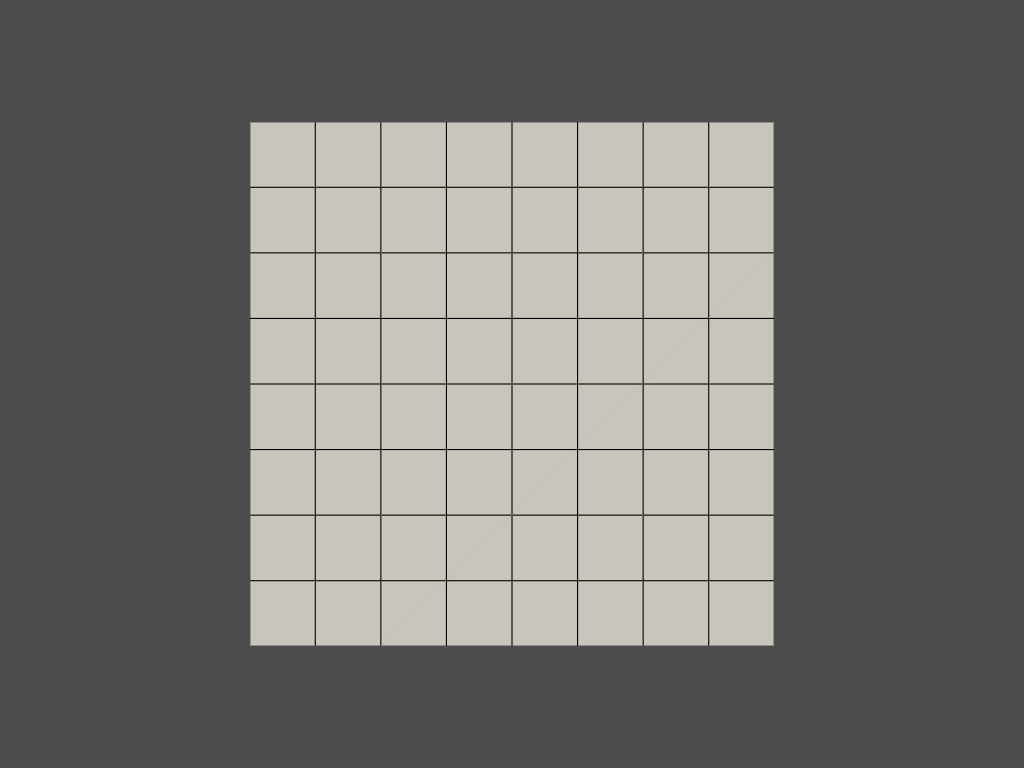

In [15]:
plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
plotter.view_xy()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    figure = plotter.screenshot("fundamentals_mesh.png")

## Trazar una función usando pyvista
Queremos representar la solución `uh`. Como el espacio de función usado para definir la malla está desconectado del espacio de función que define la malla, creamos una malla basada en las coordenadas dof para el espacio de función `V`. Usamos `dolfinx.plot.create_vtk_mesh` con el espacio de funciones como entrada para crear una malla con geometría basada en las coordenadas dof.

In [16]:
u_topology, u_cell_types, u_geometry = plot.create_vtk_mesh(V)

A continuación, creamos el `pyvista.UnstructuredGrid` y añadimos los valores dof a la malla.


Please install `ipyvtklink` to use this feature: https://github.com/Kitware/ipyvtklink

Falling back to a static output.
  warnings.warn(



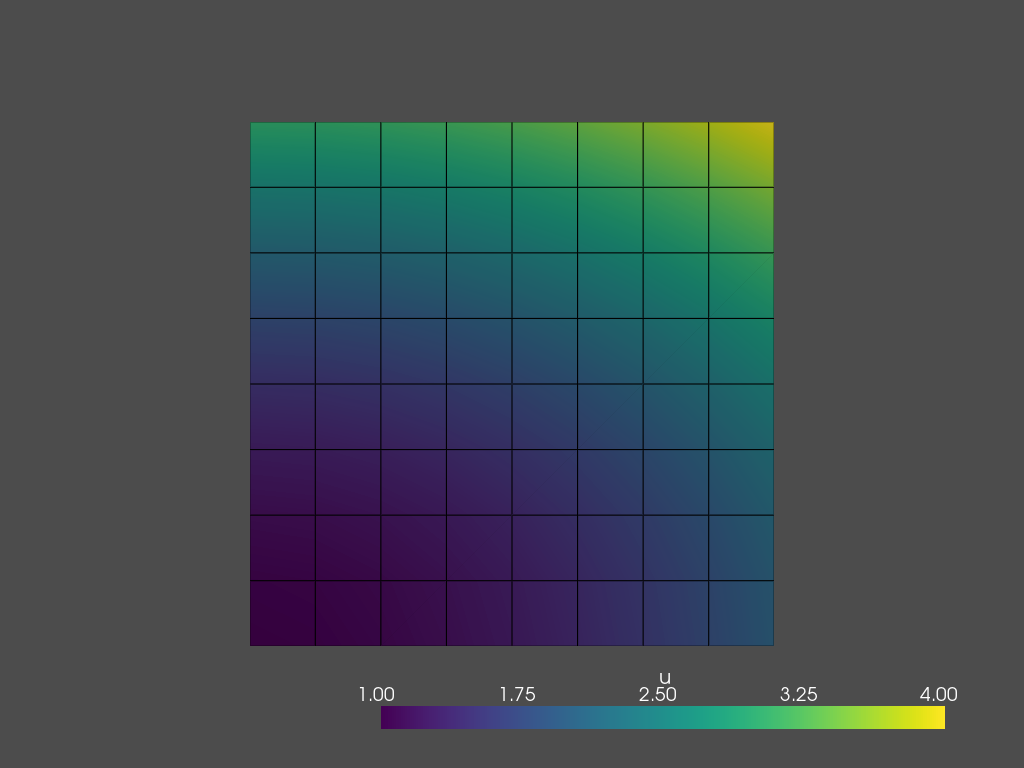

In [17]:
u_grid = pyvista.UnstructuredGrid(u_topology, u_cell_types, u_geometry)
u_grid.point_data["u"] = uh.x.array.real
u_grid.set_active_scalars("u")
u_plotter = pyvista.Plotter()
u_plotter.add_mesh(u_grid, show_edges=True)
u_plotter.view_xy()
if not pyvista.OFF_SCREEN:
    u_plotter.show()

También podemos deformar la malla mediante escalares para aprovechar el trazado 3D.

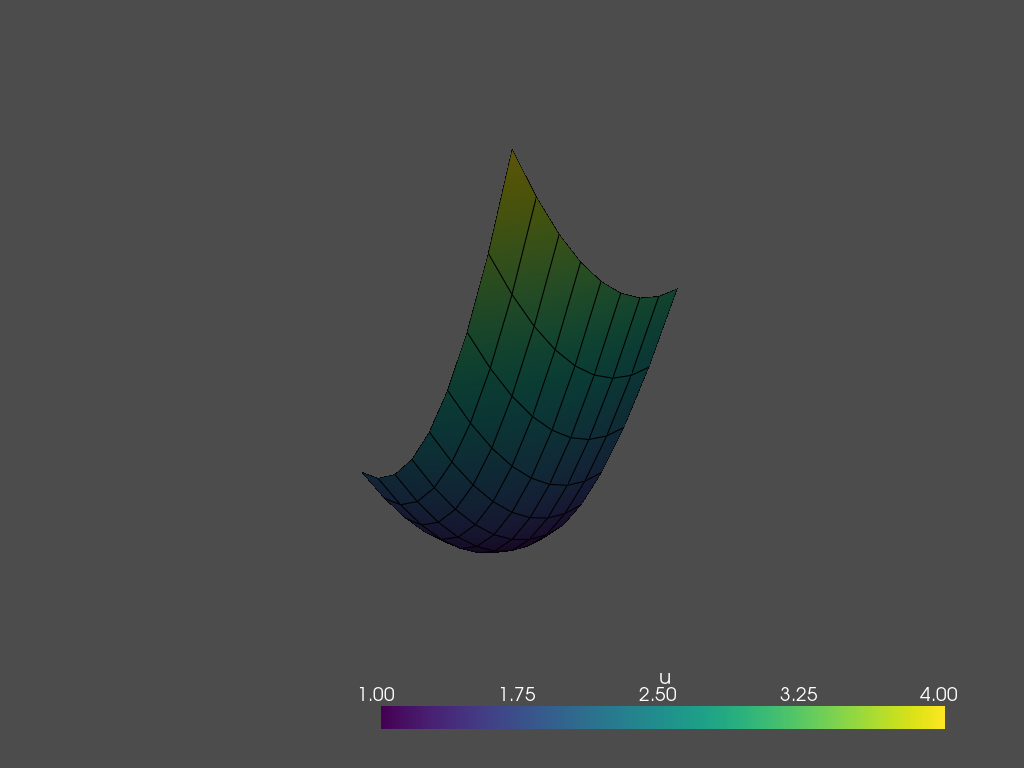

In [18]:
warped = u_grid.warp_by_scalar()
plotter2 = pyvista.Plotter()
plotter2.add_mesh(warped, show_edges=True, show_scalar_bar=True)
if not pyvista.OFF_SCREEN:
    plotter2.show()

## Post-procesamiento externo
Para el post-procesamiento fuera del código python, se sugiere guardar la solución en un archivo usando `dolfinx.io.VTXWriter` o `dolfinx.io.XDMFFile` y usando [Paraview](https://www.paraview.org/). Esto se sugiere especialmente para la visualización 3D.

In [19]:
from dolfinx import io
with io.VTXWriter(domain.comm, "output.bp", [uh]) as vtx:
    vtx.write(0.0)
with io.XDMFFile(domain.comm, "output.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)
    xdmf.write_function(uh)